In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import pickle
import sys; sys.path.insert(0, '..')

from src.migration_matrix_cci import avg_matrix, find_cci
from src.plot_function import plot_avg_matrix, plot_cci

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import data
df = pd.read_parquet(
    '../data/processed/migration_count.parquet',
    engine = 'pyarrow'
)

# Show table
df.head(5)

,date,del,del12,n
0,2014-01-31,0,0,222
1,2014-01-31,0,1,152
2,2014-01-31,0,2,88
3,2014-01-31,0,3,43
4,2014-01-31,0,4,59


In [4]:
# Constant parameters
DEL1_COL = "del" #Initial observed key
DEL12_COL = "del12" #Performance observed key
DATE_COL = "date" #Date key

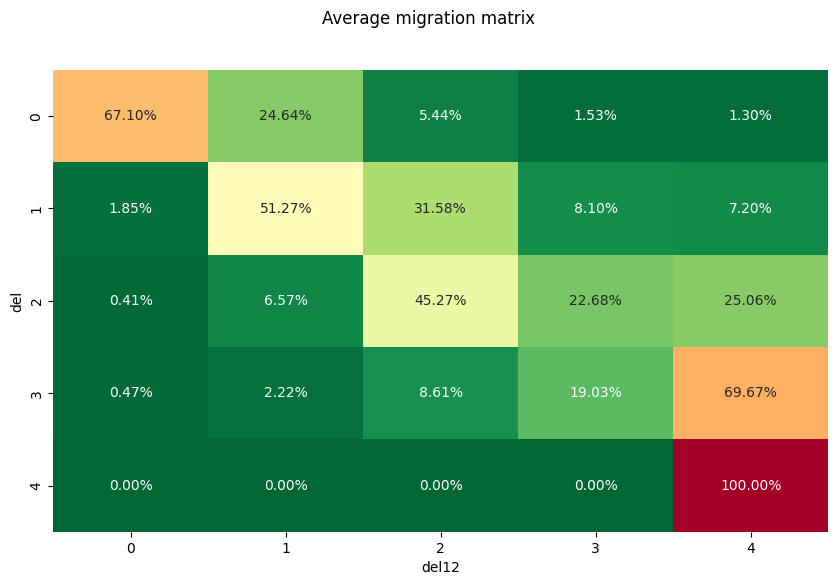

In [5]:
# Average migration matrix
average_matrix = avg_matrix(
    df,
    del1_col = DEL1_COL,
    del12_col = DEL12_COL
)

# Export (For lifetime model)
average_matrix.to_parquet(
    '../data/processed/average_matrix.parquet',
    engine = 'pyarrow'
)

# Plot
plot_avg_matrix(average_matrix)

## Credit Cycle Index
The process begins by computing the average observed migration matrix, which represents long-term transition behavior between credit states.
Next, upper bounds are derived for each migration probability. These bounds are obtained by transforming the migration rates using the inverse of the standard normal distribution (probit transformation). This step converts probabilities into threshold values in a latent normal space.

Using these thresholds, a fitted (or model-implied) migration matrix is constructed by:

$$
P_i(j) = \Phi\left(\frac{x_{i+1}^j - \sqrt{\rho}\, z_t}{\sqrt{1 - \rho}}\right)
- \Phi\left(\frac{x_i^j - \sqrt{\rho}\, z_t}{\sqrt{1 - \rho}}\right)
$$

The model is optimized by minimizing an error term for a fixed parameter $\rho$. This process is iterated until the variance of $Z_{t}$ converges to 1. The parameter $\rho$ represents the strength (weight) of the dependency between the migration rates and the common factor $CCI_{t}$ or $Z_{t}$.

$$
\min_{z_t} \sum_{j} \sum_{i}
\frac{{n_{t, G}}\left[ P_t(i,j) - \Delta\left(x_{i+1}^j,\, x_i^j,\, z_t \right) \right]^2}
{\Delta\left(x_{i+1}^j,\, x_i^j,\, z_t \right)\left[1 - \Delta\left(x_{i+1}^j,\, x_i^j,\, z_t \right)\right]}
$$

where;
- $P_t(i,j)$ denotes the observed transition rate at time $t$.
- $\Delta\left(x_{i+1}^j,\, x_i^j,\, z_t\right)$ denotes the fitted transition rate based on a predefined parameter $\rho$ and the latent factor $Z(t)$.

In [6]:
# Credit Cycle Index (CCI)
opt_result = find_cci(
    df = df,
    average_matrix = average_matrix,
    date_col = DATE_COL,
    del1_col = DEL1_COL,
    del12_col = DEL12_COL
)

# Result
opt_result

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4782.5104211502985
           x: [-2.957e+00 -2.879e+00 ...  2.481e-02  5.768e-02]
         nit: 143
         jac: [ 4.846e+01  4.699e+01 ... -7.665e+00  7.324e-04]
        nfev: 9505
        njev: 143
 multipliers: [-1.167e+03  0.000e+00]

In [ ]:
# Extract result
cci = opt_result.x[:-1] #Excluded the last position for rho
rho = opt_result.x[-1] #Only the last position for rho

# To DataFrame
cci = pd.DataFrame(
    cci,
    index = df[DATE_COL].unique(),
    columns = ["cci"]
).rename_axis(DATE_COL)

In [8]:
# Export (For FWL model)
cci.to_parquet(
    '../data/processed/monthly_cci.parquet',
    engine = 'pyarrow'
)

# Export (For lifetime model)
with open('../model/rho.pkl', 'wb') as f:
    pickle.dump(rho, f)